In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from knn import KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

In [3]:
female_data = pd.read_csv('data/ANSUR II FEMALE Public.csv', encoding="latin-1")
male_data = pd.read_csv('data/ANSUR II MALE Public.csv', encoding="latin-1")
data = pd.concat([female_data, male_data])
data.head()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10037,231,1282,301,204,1180,222,177,373,315,...,Combat Support,92Y,Germany,2,NaN,2,26,61,142,Right hand
1,10038,194,1379,320,207,1292,225,178,372,272,...,Combat Service Support,25U,California,3,Mexican,3,21,64,120,Right hand
2,10042,183,1369,329,233,1271,237,196,397,300,...,Combat Service Support,35D,Texas,1,NaN,1,23,68,147,Right hand
3,10043,261,1356,306,214,1250,240,188,384,364,...,Combat Service Support,25U,District of Columbia,8,Caribbean Islander,2,22,66,175,Right hand
4,10051,309,1303,308,214,1210,217,182,378,320,...,Combat Arms,42A,Texas,1,NaN,1,45,63,195,Right hand


In [4]:
data["weightkg"] = data["weightkg"] / 10  #Convert to kg
data["stature"] = data["stature"] / 10  #Convert to cm
data["Gender"] = data["Gender"].replace(["Female", "Male"], [0, 1])

In [5]:
female_heights = data.query("Gender == 0")["stature"]
male_heights = data.query("Gender == 1")["stature"]

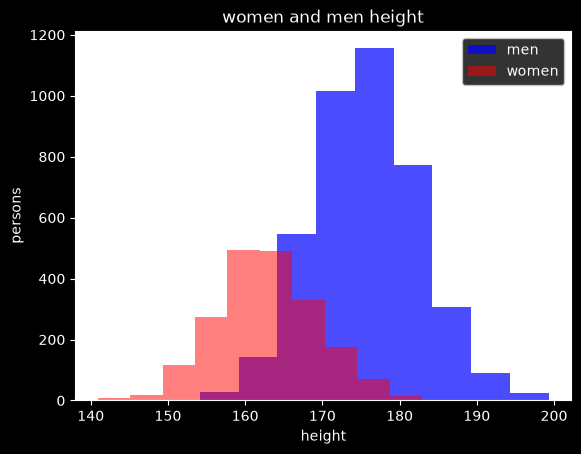

In [6]:
ax = plt.gca()
ax.set_facecolor('white')
plt.hist(male_heights, color='blue', alpha=0.7)
plt.hist(female_heights, color="red", alpha=0.5)
plt.title("women and men height")
plt.legend(["men", "women"])
plt.xlabel("height")
plt.ylabel("persons")
plt.show()

In [7]:
#X => Weight and Height Columns
#Y => Gender Column
X = data[["weightkg", "stature"]]
Y = data["Gender"].astype(int)

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=104, shuffle=True)

4982 Data From Men and 1986 Data From Women
Sum of both Data is 6068 Data.
But We Use 80% of them for Train and 20% of them for test.
so, we have 4854 Data for Train and 1214 Data for test.

In [9]:
knn_3 = KNN(k=3)
knn_5 = KNN(k=5)
knn_7 = KNN(k=7)
knn_9 = KNN(k=9)
knn_11 = KNN(k=11)

In [10]:
X_test = np.array(X_test)
X_train = np.array(X_train)
Y_test = np.array(Y_test)
Y_train = np.array(Y_train)

In [11]:
knn_3.fit(X_train, Y_train)
knn_3_accuracy = knn_3.evaluate(X_test, Y_test)
knn_3_accuracy

np.float64(0.8056013179571664)

In [12]:
knn_5.fit(X_train, Y_train)
knn_5_accuracy = knn_5.evaluate(X_test, Y_test)
knn_5_accuracy

np.float64(0.8196046128500823)

In [13]:
knn_7.fit(X_train, Y_train)
knn_7_accuracy = knn_7.evaluate(X_test, Y_test)
knn_7_accuracy

np.float64(0.8212520593080724)

In [14]:
knn_9.fit(X_train, Y_train)
knn_9_accuracy = knn_9.evaluate(X_test, Y_test)
knn_9_accuracy

np.float64(0.8303130148270181)

In [15]:
knn_11.fit(X_train, Y_train)
knn_11_accuracy = knn_11.evaluate(X_test, Y_test)
knn_11_accuracy

np.float64(0.8344316309719935)

In [16]:
y_prediction_knn_3 = knn_3.predict(X_test)
y_prediction_knn_5 = knn_5.predict(X_test)
y_prediction_knn_7 = knn_7.predict(X_test)
y_prediction_knn_9 = knn_9.predict(X_test)
y_prediction_knn_11 = knn_11.predict(X_test)

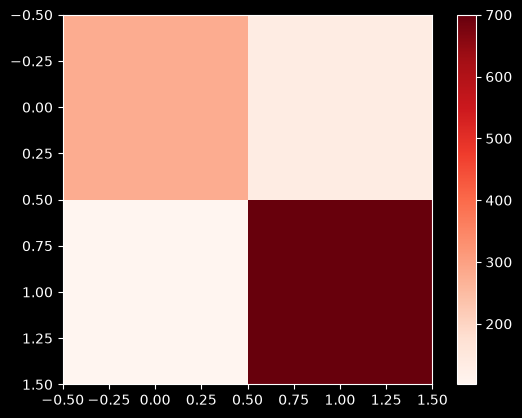

In [17]:
confusion_matrix_knn_3 = np.zeros((2,2))
for i in range(len(y_prediction_knn_3)):
    if Y_test[i] == 0 and y_prediction_knn_3[i] == 0:
        confusion_matrix_knn_3[0][0] += 1
    elif Y_test[i] == 0 and y_prediction_knn_3[i] == 1:
        confusion_matrix_knn_3[0][1] += 1
    elif Y_test[i] == 1 and y_prediction_knn_3[i] == 0:
        confusion_matrix_knn_3[1][0] += 1
    elif Y_test[i] == 1 and y_prediction_knn_3[i] == 1:
        confusion_matrix_knn_3[1][1] += 1
plt.imshow(confusion_matrix_knn_3, cmap="Reds")
plt.colorbar()
plt.show()

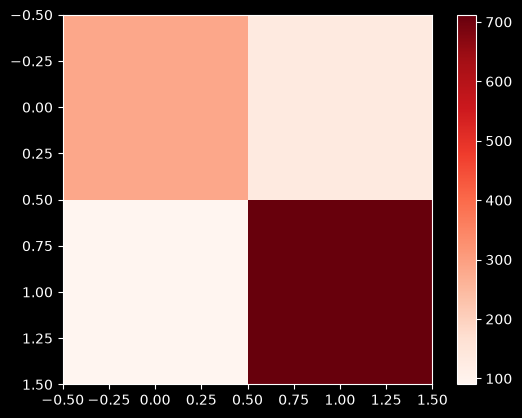

In [18]:
confusion_matrix_knn_5 = np.zeros((2,2))
for i in range(len(y_prediction_knn_5)):
    if Y_test[i] == 0 and y_prediction_knn_5[i] == 0:
        confusion_matrix_knn_5[0][0] += 1
    elif Y_test[i] == 0 and y_prediction_knn_5[i] == 1:
        confusion_matrix_knn_5[0][1] += 1
    elif Y_test[i] == 1 and y_prediction_knn_5[i] == 0:
        confusion_matrix_knn_5[1][0] += 1
    elif Y_test[i] == 1 and y_prediction_knn_5[i] == 1:
        confusion_matrix_knn_5[1][1] += 1
plt.imshow(confusion_matrix_knn_5, cmap="Reds")
plt.colorbar()
plt.show()

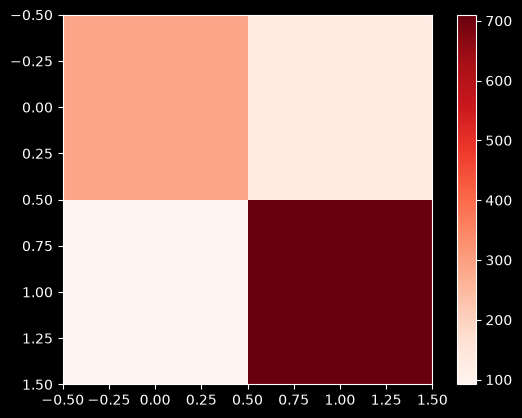

In [19]:
confusion_matrix_knn_7 = np.zeros((2,2))
for i in range(len(y_prediction_knn_7)):
    if Y_test[i] == 0 and y_prediction_knn_7[i] == 0:
        confusion_matrix_knn_7[0][0] += 1
    elif Y_test[i] == 0 and y_prediction_knn_7[i] == 1:
        confusion_matrix_knn_7[0][1] += 1
    elif Y_test[i] == 1 and y_prediction_knn_7[i] == 0:
        confusion_matrix_knn_7[1][0] += 1
    elif Y_test[i] == 1 and y_prediction_knn_7[i] == 1:
        confusion_matrix_knn_7[1][1] += 1
plt.imshow(confusion_matrix_knn_7, cmap="Reds")
plt.colorbar()
plt.show()

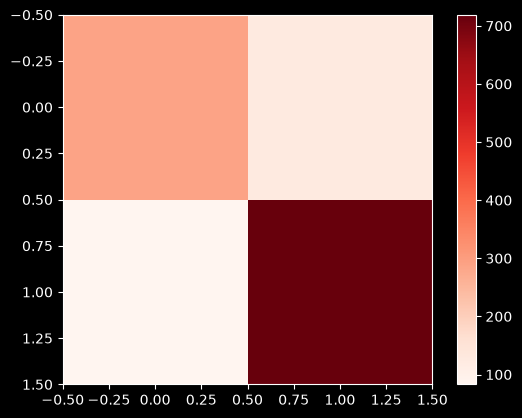

In [20]:
confusion_matrix_knn_9 = np.zeros((2,2))
for i in range(len(y_prediction_knn_9)):
    if Y_test[i] == 0 and y_prediction_knn_9[i] == 0:
        confusion_matrix_knn_9[0][0] += 1
    elif Y_test[i] == 0 and y_prediction_knn_9[i] == 1:
        confusion_matrix_knn_9[0][1] += 1
    elif Y_test[i] == 1 and y_prediction_knn_9[i] == 0:
        confusion_matrix_knn_9[1][0] += 1
    elif Y_test[i] == 1 and y_prediction_knn_9[i] == 1:
        confusion_matrix_knn_9[1][1] += 1
plt.imshow(confusion_matrix_knn_9, cmap="Reds")
plt.colorbar()
plt.show()

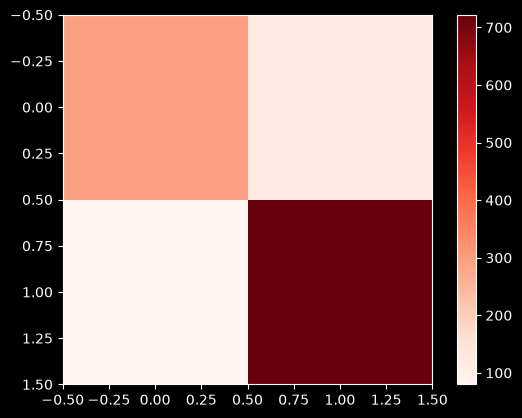

In [21]:
confusion_matrix_knn_11 = np.zeros((2,2))
for i in range(len(y_prediction_knn_11)):
    if Y_test[i] == 0 and y_prediction_knn_11[i] == 0:
        confusion_matrix_knn_11[0][0] += 1
    elif Y_test[i] == 0 and y_prediction_knn_11[i] == 1:
        confusion_matrix_knn_11[0][1] += 1
    elif Y_test[i] == 1 and y_prediction_knn_11[i] == 0:
        confusion_matrix_knn_11[1][0] += 1
    elif Y_test[i] == 1 and y_prediction_knn_11[i] == 1:
        confusion_matrix_knn_11[1][1] += 1
plt.imshow(confusion_matrix_knn_11, cmap="Reds")
plt.colorbar()
plt.show()

Now We use Scikit Learn

In [22]:
knn3_sklearn = KNeighborsClassifier(n_neighbors=3)
knn3_sklearn.fit(X_train, Y_train)
knn3_sklearn_accuracy = knn3_sklearn.score(X_test, Y_test)
knn3_sklearn_accuracy

0.8072487644151565

In [23]:
knn5_sklearn = KNeighborsClassifier(n_neighbors=5)
knn5_sklearn.fit(X_train, Y_train)
knn5_sklearn_accuracy = knn5_sklearn.score(X_test, Y_test)
knn5_sklearn_accuracy

0.8187808896210873

In [24]:
knn7_sklearn = KNeighborsClassifier(n_neighbors=7)
knn7_sklearn.fit(X_train, Y_train)
knn7_sklearn_accuracy = knn7_sklearn.score(X_test, Y_test)
knn7_sklearn_accuracy

0.8204283360790774

In [25]:
knn9_sklearn = KNeighborsClassifier(n_neighbors=9)
knn9_sklearn.fit(X_train, Y_train)
knn9_sklearn_accuracy = knn9_sklearn.score(X_test, Y_test)
knn9_sklearn_accuracy

0.8303130148270181

In [26]:
knn11_sklearn = KNeighborsClassifier(n_neighbors=11)
knn11_sklearn.fit(X_train, Y_train)
knn11_sklearn_accuracy = knn11_sklearn.score(X_test, Y_test)
knn11_sklearn_accuracy

0.8344316309719935

In [30]:
labels = ["KNN","My KNN Accuracy","Scikit-Learn KNN Accuracy"]
accuracy_list = [[3,knn_3_accuracy,knn3_sklearn_accuracy],
                 [5,knn_5_accuracy,knn5_sklearn_accuracy],
                 [7,knn_7_accuracy,knn7_sklearn_accuracy],
                 [9,knn_9_accuracy,knn9_sklearn_accuracy],
                 [11,knn_11_accuracy,knn11_sklearn_accuracy]]
accuracy_data = pd.DataFrame(accuracy_list,columns=labels)
accuracy_data

,KNN,My KNN Accuracy,Scikit-Learn KNN Accuracy
0,3,0.805601,0.807249
1,5,0.819605,0.818781
2,7,0.821252,0.820428
3,9,0.830313,0.830313
4,11,0.834432,0.834432


In [43]:
accuracy_data_numpy = accuracy_data.to_numpy()

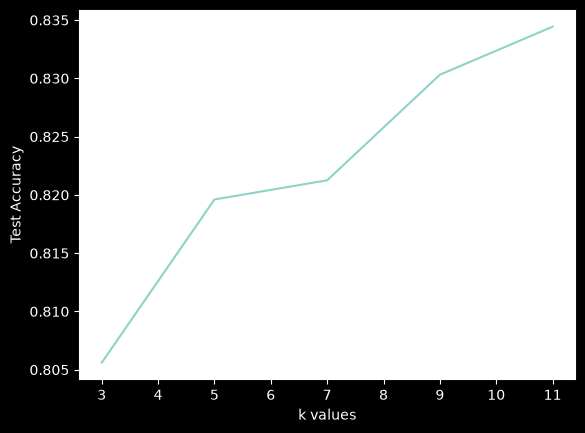

In [48]:
test_acc_list = []
k_list = []
for i in range(5):
    k_list.append(accuracy_data_numpy[i][0])
    test_acc_list.append(accuracy_data_numpy[i][1])
ax = plt.gca()
ax.set_facecolor('white')
plt.plot( k_list , test_acc_list )
plt.xlabel(" k values ")
plt.ylabel("Test Accuracy")
plt.show()